### LU Decomposition

**LU Decomposition** factorizes a square matrix \\(A\\) into the product of a lower-triangular matrix \\(L\\) (with unit diagonal) and an upper-triangular matrix \\(U\\):
$$
A = LU
$$

Once \\(A\\) is factorized, the system \\(A\mathbf{x}=\mathbf{b}\\) is solved efficiently in two steps:
$$
L\mathbf{y} = \mathbf{b} \quad \text{(forward substitution)}, \qquad U\mathbf{x} = \mathbf{y} \quad \text{(back substitution)}
$$

LU decomposition is especially efficient when solving the **same system** \\(A\mathbf{x}=\mathbf{b}\\) for **multiple right-hand sides** \\(\mathbf{b}\\), since the factorization \\(A=LU\\) only needs to be computed once.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
A = np.array([
    [2.0, 1.0, -1.0],
    [-3.0, -1.0, 2.0],
    [-2.0, 1.0, 2.0]
])
b = np.array([8.0, -11.0, -3.0])


In [3]:
def lu_decompose(A):
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()

    print("LU Decomposition steps:")
    for k in range(n - 1):
        for i in range(k + 1, n):
            factor = U[i, k] / U[k, k]
            L[i, k] = factor
            U[i, k:] -= factor * U[k, k:]

        print(f"Step {k+1}:")
        print("L =\n", L)
        print("U =\n", U)

    return L, U


In [4]:
def forward_substitution(L, b):
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])
    return y

def back_substitution(U, y):
    n = len(y)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i + 1:], x[i + 1:])) / U[i, i]
    return x

L, U = lu_decompose(A)
y = forward_substitution(L, b)
x = back_substitution(U, y)

print("\nSolution:")
for i, xi in enumerate(x):
    print(f"x{i+1} = {xi:.6f}")

print("\nVerification (L @ U):")
print(L @ U)
print("A:")
print(A)


LU Decomposition steps:
Step 1:
L =
 [[ 1.   0.   0. ]
 [-1.5  1.   0. ]
 [-1.   0.   1. ]]
U =
 [[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   2.   1. ]]
Step 2:
L =
 [[ 1.   0.   0. ]
 [-1.5  1.   0. ]
 [-1.   4.   1. ]]
U =
 [[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   0.  -1. ]]

Solution:
x1 = 2.000000
x2 = 3.000000
x3 = -1.000000

Verification (L @ U):
[[ 2.  1. -1.]
 [-3. -1.  2.]
 [-2.  1.  2.]]
A:
[[ 2.  1. -1.]
 [-3. -1.  2.]
 [-2.  1.  2.]]


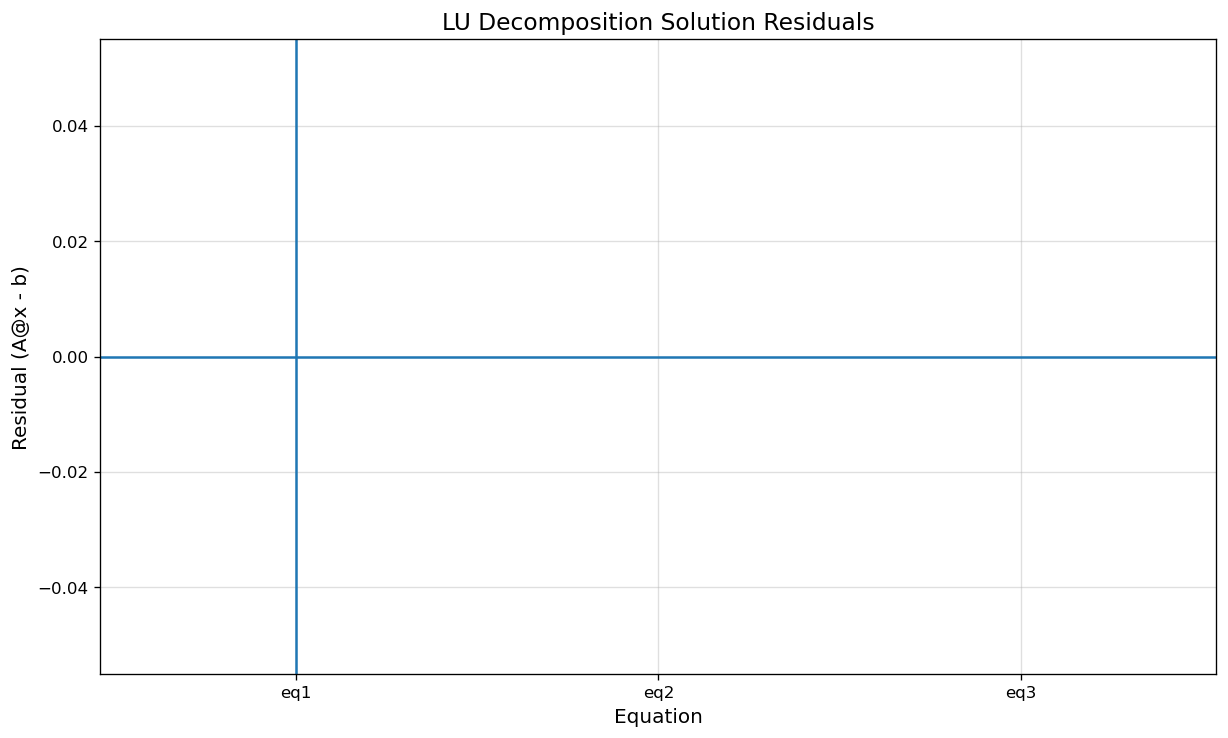

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

residual = A @ x - b
labels = [f"eq{i+1}" for i in range(len(residual))]

plt.bar(labels, residual, alpha=0.7)
plt.grid(True, alpha=0.4)
plt.xlabel("Equation", fontsize=12)
plt.ylabel("Residual (A@x - b)", fontsize=12)
plt.title("LU Decomposition Solution Residuals", fontsize=14)
plt.show()
